<a href="https://colab.research.google.com/github/fcoliveira-utfpr/aquacrop_ml/blob/main/inferencias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Início - Bibliotecas e modelos**
---

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import urllib.request
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import datetime, timedelta
import json
import requests
import os
import openpyxl
from google.colab import files

base = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/main"

modelos = {}

for nome in ["RandomForest", "XGBoost", "LightGBM"]:
    !wget -O {nome}.joblib "{base}/{nome}.joblib"
    modelos[nome] = joblib.load(f"{nome}.joblib")

#ExtraTrees
url = 'https://github.com/fcoliveira-utfpr/aquacrop_ml/releases/download/6/ExtraTrees.joblib'
filename = 'ExtraTrees.joblib'
urllib.request.urlretrieve(url, filename)

--2026-03-19 01:50:31--  https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/main/RandomForest.joblib
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17815761 (17M) [application/octet-stream]
Saving to: ‘RandomForest.joblib’

RandomForest.joblib 100%[===================>]  16.99M  --.-KB/s    in 0.1s    

2026-03-19 01:50:32 (138 MB/s) - ‘RandomForest.joblib’ saved [17815761/17815761]

--2026-03-19 01:50:32--  https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/main/XGBoost.joblib
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting respons

('ExtraTrees.joblib', <http.client.HTTPMessage at 0x7fd1a8d16960>)

# **Preparando dados**
---

In [4]:
url = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/refs/heads/main/municipios_inferencia.csv"
df = pd.read_csv(url)
df.drop(columns=['system:index', '.geo', 'estado'], inplace=True)
df.rename(columns={
    "altitude_m": "Altitude",
    "municipio": "Municipio",
    "latitude": "Latitude",
    "longitude": "Longitude"
    }, inplace=True)
df_municipios = df
url1 = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/refs/heads/main/produtividade_milho_oeste.csv"
df1 = pd.read_csv(url1)
df_filtrado = df1[df1['Localidade'].isin(df_municipios['Municipio'])].copy().reset_index(drop=True)
df_filtrado.drop(columns=['Media', 'Meedia'], inplace=True)
df_f = df_filtrado.merge(
    df_municipios,
    left_on="Localidade",
    right_on="Municipio",
    how="left"
)
df_f

,Localidade,2007,2008,2009,2010,2011,2012,2013,2014,2015,...,2017,2018,2019,2020,2021,2022,Altitude,Latitude,Longitude,Municipio
0,Céu Azul,3296,3595,2844,3495,3591,1735,3991,3736,3792,...,3965,3471,2800,4100,3526,1734,465.0,-25.246105,-53.761804,Céu Azul
1,Maripá,3071,3093,1294,3178,3300,1024,3723,3720,3269,...,3500,3800,2300,3500,3200,651,406.0,-24.444843,-53.791708,Maripá
2,Medianeira,3419,3466,1242,3590,3695,1614,3587,3644,3044,...,3720,3720,1911,4215,3719,740,401.0,-25.263159,-54.091926,Medianeira
3,Medianeira,3419,3466,1242,3590,3695,1614,3587,3644,3044,...,3720,3720,1911,4215,3719,740,401.0,-25.263159,-54.091926,Medianeira
4,Mercedes,2346,3000,1993,3043,3100,1500,3522,3153,3041,...,3500,3720,1859,3700,3000,720,326.0,-24.433409,-54.186037,Mercedes
5,Missal,3100,3471,944,3424,3342,1500,3599,2781,2227,...,3000,3600,1491,3719,3347,620,308.0,-25.095573,-54.241311,Missal
6,Palotina,2958,3166,1256,3318,3300,1347,3266,3269,3170,...,4100,3600,2375,4000,3250,352,300.0,-24.274625,-53.824060,Palotina


# **Baixando dados**
---

In [11]:
municipios = [
 'Céu Azul',
 'Medianeira',
 'Missal',
 'Mercedes',
 'Sarandi',
 'Maripá',
 'Palotina'
]

sem = ['05/02/', '15/02/', '25/02/', '05/03/', '15/03/', '25/03/']

anos = range(2007, 2023)

df_final = pd.DataFrame()

for municipio in municipios:

    for ano_inicial in anos:

        for data_sem in sem:

            try:
                estado = "PR"
                cultura = "Milho"

                # ============================================================
                # Carrega base climática local
                # ============================================================
                url_1 = "https://raw.githubusercontent.com/fcoliveira-utfpr/agrometeorologia/refs/heads/main/clima_solo_local.csv"
                df1 = pd.read_csv(url_1)

                # Separa colunas categóricas
                cidade = df1['Município']
                uf = df1['Estado']
                regiao = df1['Região']
                koppen = df1['Köppen']

                # Converte valores com vírgula para ponto e numérico
                df1_valores = df1.drop(columns=['Município', 'Estado','Região','Köppen'])
                df1_valores = df1_valores.replace({',': '.'}, regex=True)
                df1_valores = df1_valores.apply(pd.to_numeric, errors='coerce')

                # Reconstrói o df
                df1 = df1_valores.copy()
                df1['Município'] = cidade
                df1['Estado'] = uf
                df1['Região'] = regiao
                df1['Köppen'] = koppen

                # ============================================================
                # Carrega base das culturas
                # ============================================================
                url_2 = "https://raw.githubusercontent.com/fcoliveira-utfpr/agrometeorologia/refs/heads/main/dados_culturas.csv"
                df2 = pd.read_csv(url_2)

                # Separa cultura
                cult = df2['Cultura']
                df2 = df2.drop(columns=['Cultura'])

                # Converte texto para numérico
                df2_valores = df2.replace({',': '.'}, regex=True)
                df2_valores = df2_valores.apply(pd.to_numeric, errors='coerce')
                df2 = df2_valores.copy()
                df2['Cultura'] = cult

                # Filtra a cultura escolhida
                df2 = df2[(df2['Cultura'] == cultura)].copy()

                # Filtra município e estado
                df11 = df1[(df1['Município'] == municipio) & (df1['Estado'] == estado)].copy()

                # Variável do solo
                DTA = df11['DTA (mm/m)'].iloc[0]

                # Duração total da cultura
                duracao_do_ciclo = 100  # dias
                CIAFmax = 0.5
                Cc = (0.35 + 0.45)/2 # Doorenbos & Kassam (1994)
                U = (10 + 13)/2 # Doorenbos & Kassam (1994)

                # % de duração das fases
                fase1 = df2['F1 %'].iloc[0]
                fase2 = df2['F2 %'].iloc[0]
                fase3 = df2['F3 %'].iloc[0]
                fase4 = df2['F4 %'].iloc[0]

                # Kc nas fases
                kc1 = df2['Kc ini'].iloc[0]
                kc2 = df2['Kc méd'].iloc[0]
                kc3 = df2['Kc fin'].iloc[0]

                ky1 = df2['ky1'].iloc[0]
                ky2 = df2['ky2'].iloc[0]
                ky3 = df2['ky3'].iloc[0]
                ky4 = df2['ky4'].iloc[0]

                # Profundidade radicular
                z_inicial = 0.05
                z_final = df2['Z efetivo (m)'].iloc[0]

                # Metadados do local
                nome_cidade = df11["Município"].iloc[0]
                latitude = df11["latitude"].iloc[0]
                longitude = df11["longitude"].iloc[0]
                alt = df11["Altitude"].iloc[0]

                # ============================================================
                # Download de dados NASA POWER
                # ============================================================

                # Define período de coleta
                ano_final = ano_inicial+1
                data_ini = datetime(ano_inicial, 1, 1).date()
                data_fim = datetime(ano_final, 12, 31).date()

                # Formata datas para API
                ini = int(data_ini.strftime('%Y%m%d'))
                fin = int(data_fim.strftime('%Y%m%d'))

                # Monta URL da requisição
                base_url = (
                    "https://power.larc.nasa.gov/api/temporal/daily/point"
                    "?parameters=T2M_MIN,T2M_MAX,PRECTOTCORR,RH2M,WS2M,ALLSKY_SFC_SW_DWN,TOA_SW_DWN"
                    "&community=RE"
                    "&longitude={longitude}"
                    "&latitude={latitude}"
                    "&start={ini}"
                    "&end={fin}"
                    "&format=JSON"
                )

                api_request_url = base_url.format(
                    longitude=longitude,
                    latitude=latitude,
                    ini=ini,
                    fin=fin
                )

                # Requisição
                response = requests.get(url=api_request_url, verify=True, timeout=120)
                response.raise_for_status()

                # Extração dos parâmetros
                dados_json = response.json()
                propriedades = dados_json['properties']
                parametros = propriedades['parameter']

                # Datas
                datas_str = sorted(list(parametros['T2M_MIN'].keys()))
                datas = [pd.to_datetime(d) for d in datas_str]

                # Constrói DataFrame com variáveis
                df = pd.DataFrame({'Data': datas})
                df['Tmin'] = [parametros['T2M_MIN'][d] for d in datas_str]
                df['Tmax'] = [parametros['T2M_MAX'][d] for d in datas_str]
                df['Chuva'] = [parametros['PRECTOTCORR'][d] for d in datas_str]
                df['UR'] = [parametros['RH2M'][d] for d in datas_str]
                df['U2'] = [parametros['WS2M'][d] for d in datas_str]
                df['Rs_raw'] = [parametros['ALLSKY_SFC_SW_DWN'][d] for d in datas_str]
                df['Qo_raw'] = [parametros['TOA_SW_DWN'][d] for d in datas_str]

                # Converte radiação para MJ/m²
                df['Rs'] = df['Rs_raw'] * 3.6
                df['Qo'] = df['Qo_raw'] * 3.6

                # Variáveis intermediárias
                df['Tmed'] = (df['Tmax'] + df['Tmin']) / 2
                df['Patm'] = 101.3 * ((293 - 0.0065 * alt) / 293) ** 5.26
                df['NDA'] = [pd.to_datetime(d).timetuple().tm_yday for d in df['Data']]

                # Declinação solar
                def dec_sol(NDA):
                    return 23.45 * np.sin(np.deg2rad(360/365 * (NDA - 80)))

                df['d'] = df['NDA'].apply(dec_sol)

                # Hora de nascer do sol
                def hora_na_sol(d, Lat):
                    return np.rad2deg(np.arccos(-(np.tan(np.deg2rad(Lat)) * np.tan(np.deg2rad(d)))))

                df['Hn'] = df['d'].apply(lambda d_: hora_na_sol(d_, latitude))


                # (d/D)^2
                def relacao_d_D_2(NDA):
                    return 1 + 0.033 * np.cos(np.deg2rad(NDA * 360/365))
                df['(d/D)²'] = df['NDA'].apply(relacao_d_D_2)

                # Balanços radiativos
                df['BOC'] = df['Rs'] * 0.75  # (1 - 25%)

                df['N'] = df.apply(lambda x: (2 * x['Hn']) / 15, axis = 1)

                #determinando a insolação - n
                df['n_inso'] = df.apply(lambda x: (((x['Rs']/x['Qo'])  - (0.29 * np.cos(latitude)))/0.52) * x['N'], axis=1)

                def e_saturacao(temp):
                    return 0.6108 * 10 ** ((7.5 * temp) / (237.3 + temp))

                df['es_Tmax'] = df['Tmax'].apply(e_saturacao)
                df['es_Tmin'] = df['Tmin'].apply(e_saturacao)
                df['es'] = (df['es_Tmax'] + df['es_Tmin']) / 2
                df['ea'] = (df['UR']/100) * df['es']
                df['QGcs'] = df['Qo'] * (0.75 + (2e-5)*alt)

                def BOL(tmax, tmin, eaa, qg, qgcs):
                    a = 4.903e-9 * (((tmax+273.16)**4 + (tmin+273.16)**4)/2)
                    b = (0.34 - 0.14*np.sqrt(eaa))
                    c = 1.35*(qg/qgcs) - 0.35
                    return -(a*b*c)

                df['BOL'] = df.apply(lambda x: BOL(x['Tmax'],x['Tmin'],x['ea'],x['Rs'],x['QGcs']), axis=1)
                df['Rn'] = df['BOC'] + df['BOL']

                df['s'] = (4098 * df['es']) / (df['Tmed'] + 237.3)**2
                df['gama'] = 0.665e-3 * df['Patm']

                # Penman-Monteith
                def ETo(s,Rn,gama,u2,es,ea,tmed):
                    ETo1 = 0.408*s*Rn
                    ETo2 = (gama*900*u2*(es-ea))/(tmed+273)
                    ETo3 = s + gama*(1+0.34*u2)
                    return (ETo1 + ETo2)/ETo3

                df['ETo'] = df.apply(lambda x: ETo(x['s'],x['Rn'],x['gama'],x['U2'],x['es'],x['ea'],x['Tmed']), axis=1)

                # Metadados no df
                df['Municipio'] = nome_cidade
                df['Lat'] = latitude
                df['Lon'] = longitude
                df['Alt'] = alt

                df.replace(-999, np.nan, inplace=True)
                df.interpolate(inplace=True)

                # ============================================================
                # Fases fenológicas da cultura
                # ============================================================

                fasetotal = fase1 + fase2 + fase3 + fase4
                fase1d = (duracao_do_ciclo * fase1)/fasetotal
                fase2d = (duracao_do_ciclo * fase2)/fasetotal
                fase3d = (duracao_do_ciclo * fase3)/fasetotal
                fase4d = (duracao_do_ciclo * fase4)/fasetotal

                # Incrementos de Kc e Z
                acrescimo_kc1 = (kc2 - kc1)/fase2d
                acrescimo_kc2 = (kc3 - kc2)/fase4d
                acrescimo_z = (z_final - z_inicial)/(fase1d + fase2d)

                # ============================================================
                # Datas de semeadura e maturação
                # ============================================================

                data_semeadura = datetime.strptime(f'{data_sem}{ano_inicial}', '%d/%m/%Y')
                data_maturacao = data_semeadura + timedelta(days=duracao_do_ciclo-1)

                df1 = pd.DataFrame({
                    'Datas de semeadura': [data_semeadura],
                    'Datas maturação': [data_maturacao]
                })

                #**************SIMULAÇÃO DE PRODUTIVIDADE**************************************************
                safra1 = (df.loc[(df['Data'] >= df1['Datas de semeadura'][0]) & (df['Data'] <= df1['Datas maturação'][0])]).copy()

                safra1['n'] = list(range(1, safra1['NDA'].count() +1))

                # -------------------------------
                # 1) Kc e FASE da cultura (igual prof)
                # -------------------------------
                fase_cultura = []
                Kc1 = []

                for n in safra1['n']:
                    if n <= fase1d:
                        # Fase 1: Kc = kc1
                        Kc1.append(kc1)
                        fase_cultura.append(1)

                    elif n <= fase1d + fase2d:
                        # Fase 2: crescimento linear kc1 -> kc2
                        Kc1.append(Kc1[-1] + acrescimo_kc1)
                        fase_cultura.append(2)

                    elif n <= fase1d + fase2d + fase3d:
                        # Fase 3: Kc constante = kc2
                        Kc1.append(kc2)
                        fase_cultura.append(3)

                    else:
                        # Fase 4: decaimento linear kc2 -> kc3
                        Kc1.append(Kc1[-1] + acrescimo_kc2)
                        fase_cultura.append(4)

                safra1['Kc'] = Kc1
                safra1['Fase'] = fase_cultura

                # -------------------------------
                # 2) Crescimento da raiz z
                # -------------------------------
                z1 = []
                for n in safra1['n']:
                    if n == 1:
                        z1.append(z_inicial + acrescimo_z)
                    elif n <= fase1d + fase2d:
                        z1.append(z1[-1] + acrescimo_z)
                    else:
                        z1.append(z_final)

                safra1['z'] = z1

                # -------------------------------
                # 3) CAD, ETc, P-ETc
                # -------------------------------
                safra1['CAD'] = safra1['z'] * DTA          # CAD (mm) no perfil explorado
                safra1['ETc'] = safra1['Kc'] * safra1['ETo']    # ETc diária
                safra1['P-ETc'] = safra1['Chuva'] - safra1['ETc']

                # -------------------------------
                # 4) ARM (armazenamento de água no solo)
                # -------------------------------
                PETc1 = safra1['P-ETc'].to_numpy()
                CAD1 = safra1['CAD'].to_numpy()

                # Estado inicial de ARM (solo cheio na profundidade inicial)
                ARM1 = [z_inicial * DTA]

                for p, cad in zip(PETc1, CAD1):
                    prev = ARM1[-1]
                    if p < 0:
                        # Déficit: usa equação exponencial (igual professor)
                        ARM1.append(prev * np.exp(p / cad))
                    elif p + prev >= cad:
                        # Encharcou: limita ao CAD
                        ARM1.append(cad)
                    else:
                        # Situação normal
                        ARM1.append(prev + p)

                # Remove o estado inicial e deixa só os valores correspondentes aos dias
                ARM1 = ARM1[1:]
                safra1['ARM'] = ARM1

                # -------------------------------
                # 5) ALT (variação diária de ARM)
                # -------------------------------
                ALT = [0]  # primeiro dia, variação zero
                ALT += list(np.array(ARM1[1:]) - np.array(ARM1[:-1]))
                safra1['ALT'] = ALT

                # -------------------------------
                # 6) ETR, DEF, EXC, ISNA diário
                # -------------------------------
                safra1['ETR'] = np.where(
                    safra1['P-ETc'] < 0,
                    safra1['Chuva'] + safra1['ALT'].abs(),  # solo complementa a chuva
                    safra1['ETc']                           # sem limitação hídrica
                )

                safra1['DEF'] = safra1['ETc'] - safra1['ETR']

                safra1['EXC'] = np.where(
                    safra1['ARM'] < safra1['CAD'],
                    0,
                    safra1['P-ETc'] - safra1['ALT']
                )

                safra1['ISNA_diario'] = safra1['ETR'] / safra1['ETc']

                safra1['n/N'] = safra1.apply(lambda x: x['n_inso']/x['N'], axis=1)

                safra1['qo'] = safra1.apply(lambda x: x['Qo'] * 23.9234, axis=1)

                safra1['cTc'] = safra1.apply(lambda x: -4.16 + (0.4325 * x['Tmed']) - (0.00725 * (x['Tmed'])**2), axis=1)

                safra1['cTn'] = safra1.apply(lambda x: -1.064 + (0.173 * x['Tmed']) + (0.0029 * (x['Tmed'])**2), axis=1)

                safra1['PPBp'] = safra1.apply(
                    lambda x: ((107.2 + 0.36 * x['qo']) * x['cTc'] * x['n/N']) +
                              ((31.7 + 0.219 * x['qo']) * x['cTn'] * (1 - x['n/N'])),
                    axis=1
                )

                # correção aqui
                safra1['CR'] = np.where(safra1['Tmed'] >= 20, 0.5, 0.6)

                safra1['PP'] = (safra1['PPBp'] * CIAFmax * safra1['CR'] * Cc)/(1 - 0.01 * U)

                Bp = safra1['PP'].sum()

                def rc(safra):

                    rc_1 = safra['ETR'][0:int(fase1d)].sum() / safra['ETc'][0:int(fase1d)].sum()

                    rc_2 = safra['ETR'][int(fase1d):int(fase1d + fase2d)].sum() / \
                          safra['ETc'][int(fase1d):int(fase1d + fase2d)].sum()

                    rc_3 = safra['ETR'][int(fase1d + fase2d):int(fase1d + fase2d + fase3d)].sum() / \
                          safra['ETc'][int(fase1d + fase2d):int(fase1d + fase2d + fase3d)].sum()

                    rc_4 = safra['ETR'][int(fase1d + fase2d + fase3d):int(fase1d + fase2d + fase3d + fase4d)].sum() / \
                          safra['ETc'][int(fase1d + fase2d + fase3d):int(fase1d + fase2d + fase3d + fase4d)].sum()

                    return [rc_1, rc_2, rc_3, rc_4]


                rc_vals = rc(safra1)

                rc_1, rc_2, rc_3, rc_4 = rc_vals

                PA1 = (1 - ky1 * (1 - rc_1)) * Bp
                PA2 = (1 - ky2 * (1 - rc_2)) * PA1
                PA3 = (1 - ky3 * (1 - rc_3)) * PA2
                PA4 = (1 - ky4 * (1 - rc_4)) * PA3


                # -----------------------------------------
                # Resumo por fase das principais variáveis
                # -----------------------------------------

                safra = safra1.groupby("Fase").agg({
                    "Tmin": "mean",
                    "Tmax": "mean",
                    "Tmed": "mean",
                    "Chuva": "sum",
                    "UR": "mean",
                    "ETc": "sum",
                    'ETR': "sum",
                    "ARM": "last",
                    "DEF": "sum",
                    "EXC": "sum",
                    "N": "mean",
                    "PP": "sum"
                })
                safra['Data semeadura'] = df1['Datas de semeadura'].iloc[0]
                safra['Data maturação'] = df1['Datas maturação'].iloc[0]

                safra = safra.reset_index()
                safra['ISNA'] = [rc_1, rc_2, rc_3, rc_4]
                safra['PA'] = [PA1, PA2, PA3, PA4]

                safra

                # ------------------------------------------------
                # RESULTADO FINAL
                # ------------------------------------------------

                safra['Municipio'] = municipio
                safra['Ano'] = ano_inicial

                df_final = pd.concat([df_final, safra], ignore_index=True)
                print(f"OK -> {municipio} {ano_inicial} {data_sem}")

            except:
                print(f"ERRO -> {municipio} {ano_inicial} {data_sem}")

/tmp/ipykernel_8658/1261744774.py:235: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(inplace=True)


OK -> Céu Azul 2007 05/02/


/tmp/ipykernel_8658/1261744774.py:235: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(inplace=True)


OK -> Céu Azul 2007 15/02/


/tmp/ipykernel_8658/1261744774.py:235: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(inplace=True)


...

/tmp/ipykernel_8658/1261744774.py:235: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(inplace=True)


OK -> Palotina 2022 05/03/


/tmp/ipykernel_8658/1261744774.py:235: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(inplace=True)


OK -> Palotina 2022 15/03/
OK -> Palotina 2022 25/03/


/tmp/ipykernel_8658/1261744774.py:235: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(inplace=True)


In [12]:
df_final.to_csv('df_final_inferencia.csv', index=False)

# **Feature engineering**
---

In [5]:
url = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/refs/heads/main/df_final_inferencia.csv"
df = pd.read_csv(url)
df["Amp"] = df['Tmax'] - df['Tmin']
df["Pefetiva"] = df["Chuva"] / df['ETc']
df['T_DEF'] = df['Tmax'] * df['DEF']
df.columns
df_yield = df_f.melt(
    id_vars=['Municipio','Latitude','Longitude','Altitude'],
    value_vars=[str(y) for y in range(2007, 2022)],
    var_name='Ano',
    value_name='Yield_obs'
)
df_yield['Ano'] = df_yield['Ano'].astype(int)
df_yield['lat_lon'] = df_yield['Latitude'] * df_yield['Longitude']
df_model = df.merge(df_yield, on=['Municipio','Ano'], how='left')
df_model['Data semeadura'] = pd.to_datetime(df_model['Data semeadura'])
df_model['Data maturação'] = pd.to_datetime(df_model['Data maturação'])
df_model['DOY_semeadura'] = df_model['Data semeadura'].dt.dayofyear
df_model['DOY_maturacao'] = df_model['Data maturação'].dt.dayofyear
df_model = df_model.drop(columns=['Data semeadura', 'Data maturação'])
vars_fase = ['Tmin','Tmax','Tmed','Chuva','UR','ETc','ETR','ARM',
             'DEF','EXC','ISNA','PA','Amp','Pefetiva','Latitude',
             'Longitude','Altitude', 'lat_lon', 'T_DEF' ]

df_wide = df_model.pivot_table(
    index=['Municipio','Ano','Yield_obs','DOY_semeadura','DOY_maturacao'],
    columns='Fase',
    values=vars_fase
)
df_wide.columns = [f'{v}_F{f}' for v,f in df_wide.columns]
df_wide = df_wide.reset_index()
df_wide.drop(columns=['Municipio','Altitude_F2','Altitude_F3',
                      'Altitude_F4', 'Latitude_F2', 'Latitude_F3', 'Latitude_F4',
                      'Longitude_F2', 'Longitude_F3', 'Longitude_F4',
                      'lat_lon_F2', 'lat_lon_F3', 'lat_lon_F4'
                      ], inplace=True)
df_wide

,Ano,Yield_obs,DOY_semeadura,DOY_maturacao,ARM_F1,ARM_F2,ARM_F3,ARM_F4,Altitude_F1,Amp_F1,...,Tmed_F4,Tmin_F1,Tmin_F2,Tmin_F3,Tmin_F4,UR_F1,UR_F2,UR_F3,UR_F4,lat_lon_F1
0,2007,3296.0,36,135,22.741333,35.002837,28.081445,42.888944,465.0,9.272941,...,18.712955,19.624118,19.572143,18.454242,13.529545,81.292353,80.520357,77.827879,84.693636,1357.276163
1,2007,3296.0,46,145,22.741333,14.451884,33.680672,47.225405,465.0,8.871176,...,16.982273,19.844118,19.276071,17.116667,12.093182,83.791765,76.961071,81.852121,85.776364,1357.276163
2,2007,3296.0,56,155,18.438097,40.124051,41.020608,42.704309,465.0,10.136471,...,14.051136,20.152353,18.619286,15.293636,8.916364,78.872353,77.944643,82.984242,84.844545,1357.276163
3,2007,3296.0,64,163,17.578963,36.652552,49.920000,33.883580,465.0,9.893529,...,13.762955,19.010000,18.647500,14.405152,8.211818,79.010000,78.126071,84.683333,83.268182,1357.276163
4,2007,3296.0,74,173,9.589757,42.905467,36.212179,23.048701,465.0,11.058824,...,16.755000,18.650588,17.426786,11.220606,11.347727,76.920000,81.159643,84.592121,83.524545,1357.276163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
535,2021,3250.0,46,145,19.935111,12.900589,0.819018,11.152428,300.0,10.445882,...,19.744545,19.157647,19.458929,16.252727,12.731364,76.655294,75.200357,63.474848,63.159091,1306.558871
536,2021,3250.0,56,155,8.230043,5.829224,11.250600,11.582178,300.0,10.444706,...,20.015227,19.016471,19.023929,15.334242,13.157273,74.832941,72.202500,63.235758,65.296364,1306.558871
537,2021,3250.0,64,163,15.585872,4.605555,7.439210,41.888945,300.0,11.127059,...,19.689318,19.002941,18.433571,14.058788,13.810909,73.642941,69.149643,62.269697,72.286364,1306.558871
538,2021,3250.0,74,173,15.383582,2.609589,10.720750,43.513260,300.0,10.473529,...,18.133409,20.110000,16.623214,13.382727,12.644545,76.865882,64.291429,63.004545,79.549091,1306.558871


In [ ]:
df_wide.to_csv('df_wide_inferencia.csv', index=False)

In [10]:
altitude = [465, 406, 401, 326, 308, 300]
df_ceuazul = df_wide[df_wide['Altitude_F1'] == 465]
#df_ceuazul = df_ceuazul[df_ceuazul['DOY_semeadura'] == 84]
df_missal = df_wide[df_wide['Altitude_F1'] == 465]
df_missal = df_missal[df_missal['DOY_semeadura'] == 84]
df_missal

,Ano,Yield_obs,DOY_semeadura,DOY_maturacao,ARM_F1,ARM_F2,ARM_F3,ARM_F4,Altitude_F1,Amp_F1,...,Tmed_F4,Tmin_F1,Tmin_F2,Tmin_F3,Tmin_F4,UR_F1,UR_F2,UR_F3,UR_F4,lat_lon_F1
5,2007,3296.0,84,183,19.108399,49.920000,29.784006,16.703449,465.0,11.285294,...,16.325682,19.185882,16.306429,9.484242,10.656818,76.585294,83.262857,84.599394,82.029091,1357.276163
17,2009,2844.0,84,183,14.189717,49.920000,49.920000,49.705647,465.0,13.487059,...,14.147273,18.660588,14.742500,11.606667,8.833182,65.841765,65.422857,82.448485,87.740909,1357.276163
23,2010,3495.0,84,183,11.828749,49.920000,40.792948,30.038780,465.0,9.897647,...,17.769773,16.848235,14.977857,10.425758,12.745909,83.464706,84.082857,87.983030,86.981364,1357.276163
29,2011,3591.0,84,183,10.095086,18.804697,31.305261,49.920000,465.0,10.800000,...,15.982955,17.403529,15.453571,11.220909,10.405000,81.049412,81.070357,76.377273,81.790909,1357.276163
41,2013,3991.0,84,183,19.570502,33.773567,37.383981,48.138658,465.0,11.521176,...,16.280227,16.241176,12.916786,12.760909,12.218182,78.840588,74.356071,85.418485,91.311818,1357.276163
47,2014,3736.0,84,183,22.741333,31.596022,47.190499,47.514348,465.0,10.010000,...,16.602045,19.008235,15.260714,11.838182,12.108182,81.111765,86.969286,88.276667,88.636364,1357.276163
53,2015,3792.0,84,183,14.009184,36.885116,30.504751,49.920000,465.0,12.780000,...,16.576136,17.090588,15.702857,13.917273,11.360909,71.441176,76.371429,83.956364,83.001818,1357.276163
65,2017,3965.0,84,183,22.741333,38.756710,47.919095,29.054299,465.0,10.145294,...,16.475455,17.682941,14.450714,14.690000,11.084091,81.704118,84.691429,90.047576,87.622273,1357.276163
71,2018,3471.0,84,183,8.890091,4.945706,42.535528,47.762119,465.0,9.188235,...,16.881591,16.618235,16.874643,11.323333,11.615455,86.000588,80.815000,82.900000,84.020000,1357.276163
77,2019,2800.0,84,183,16.112492,49.920000,34.819854,32.957769,465.0,10.306471,...,18.784091,17.587647,17.634643,13.547879,13.770455,81.368824,82.222143,87.523333,86.247727,1357.276163


# **Inferencia dos modelos**

In [ ]:
modelo_et = joblib.load('ExtraTrees.joblib')
modelo_rf = joblib.load("RandomForest.joblib")
modelo_xgb = joblib.load("XGBoost.joblib")
modelo_lgbm = joblib.load("LightGBM.joblib")

features = ['UR_F1', 'T_DEF_F1', 'DEF_F1', 'Tmax_F1', 'Tmed_F2', 'Tmed_F1',
       'Tmax_F2', 'UR_F2', 'ISNA_F1', 'Tmin_F2', 'Tmin_F3', 'T_DEF_F2',
       'ETc_F1', 'DEF_F2', 'Altitude_F1', 'Amp_F4', 'Tmin_F1', 'Pefetiva_F1',
       'PA_F2', 'Tmed_F3', 'Chuva_F1', 'Tmin_F4', 'ISNA_F2', 'PA_F3', 'EXC_F1',
       'Longitude_F1', 'PA_F4', 'Amp_F3', 'Chuva_F2', 'ARM_F1', 'ETR_F4',
       'EXC_F2', 'ETR_F2', 'Pefetiva_F2', 'ARM_F3', 'Tmed_F4', 'ARM_F2',
       'Tmax_F3', 'ETc_F2', 'ETR_F1', 'Amp_F1', 'Latitude_F1', 'ETR_F3',
       'UR_F4', 'T_DEF_F4', 'DEF_F4', 'ISNA_F3', 'Pefetiva_F4', 'ISNA_F4',
       'UR_F3', 'Tmax_F4', 'lat_lon_F1', 'EXC_F3', 'ETc_F3', 'ETc_F4', 'PA_F1',
       'Chuva_F3', 'ARM_F4', 'DEF_F3', 'Chuva_F4', 'Amp_F2', 'EXC_F4',
       'Pefetiva_F3', 'T_DEF_F3', 'DOY_semeadura', 'DOY_maturacao']

In [ ]:
doy_sem = [36, 46, 56, 64, 74, 84, 65, 75, 85]

for data in doy_sem:
  df_datas = df_ceuazul[df_ceuazul['DOY_semeadura'] == data]
  df_datas.drop(columns=['Ano'], inplace=True)

  # FEATURES
  X_novo = df_datas[features]

  # TARGET
  y_novo = df_datas['Yield_obs']

  y_pred = modelo_et.predict(X_novo)

  # ==========================================================
  # MÉTRICAS
  # ==========================================================

  mae = mean_absolute_error(y_novo, y_pred)
  mse = mean_squared_error(y_novo, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_novo, y_pred)
  mape = np.mean(np.abs((y_novo - y_pred) / (y_novo + 1e-6))) * 100
r2

/tmp/ipykernel_2855/1931319959.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_datas.drop(columns=['Ano'], inplace=True)
/tmp/ipykernel_2855/1931319959.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_datas.drop(columns=['Ano'], inplace=True)
/tmp/ipykernel_2855/1931319959.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_datas.drop(columns=['Ano'], inplace=True)
/tmp/ipykernel_2855/1931319959.py:5: SettingWithCopyWar

0.9622789469802696

In [ ]:
resultados = []

doy_sem = [36, 46, 56, 64, 74, 84, 65, 75, 85]

for data in doy_sem:

    df_datas = df_ceuazul[df_ceuazul['DOY_semeadura'] == data].copy()
    df_datas.drop(columns=['Ano'], inplace=True)

    # FEATURES
    X_novo = df_datas[features]

    # TARGET
    y_novo = df_datas['Yield_obs']

    # PREDIÇÃO
    y_pred = modelo_et.predict(X_novo)

    # MÉTRICAS
    mae = mean_absolute_error(y_novo, y_pred)
    mse = mean_squared_error(y_novo, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_novo, y_pred)
    mape = np.mean(np.abs((y_novo - y_pred) / (y_novo + 1e-6))) * 100

    # SALVAR RESULTADOS
    resultados.append({
        'DOY': data,
        'n_amostras': len(df_datas),
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAPE (%)': mape
    })

# TRANSFORMAR EM DATAFRAME
df_resultados = pd.DataFrame(resultados)

# OPCIONAL: ordenar
df_resultados = df_resultados.sort_values('DOY')

df_resultados

,DOY,n_amostras,MAE,MSE,RMSE,R2,MAPE (%)
0,36,15,211.543658,56652.620760,238.018110,0.831847,5.894003
1,46,15,184.028224,47774.441178,218.573652,0.858199,5.194398
2,56,15,208.398939,58173.734522,241.192319,0.827332,6.232719
3,64,11,187.223360,48085.212805,219.283408,0.663105,5.255396
6,65,4,126.703520,28406.071563,168.541009,0.966077,3.502970
4,74,11,230.834200,65363.123384,255.662127,0.542052,6.545237
7,75,4,196.973910,46226.894730,215.004406,0.944794,6.810012
5,84,11,200.562001,55297.127038,235.153412,0.612577,5.722709
8,85,4,158.320897,31586.070308,177.724704,0.962279,4.857816


In [ ]:
y_obs_total = []
y_pred_total = []

doy_sem = [36, 46, 56, 64, 74, 84, 65, 75, 85]

for data in doy_sem:

    df_datas = df_ceuazul[df_ceuazul['DOY_semeadura'] == data].copy()
    df_datas.drop(columns=['Ano'], inplace=True)

    X_novo = df_datas[features]
    y_novo = df_datas['Yield_obs']

    y_pred = modelo_et.predict(X_novo)

    # acumular
    y_obs_total.extend(y_novo.values)
    y_pred_total.extend(y_pred)

ValueError: 'c' argument has 36 elements, which is inconsistent with 'x' and 'y' with size 90.

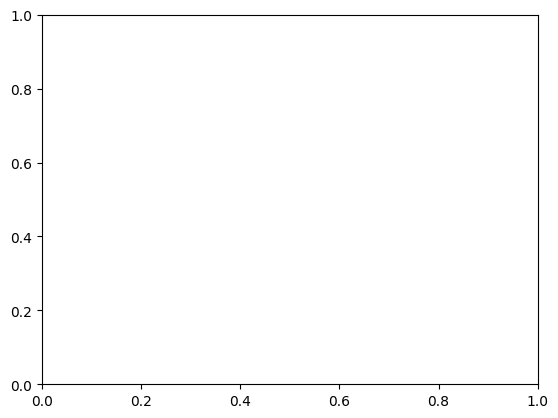

In [32]:
doy_total = []

for data in doy_sem:
    ...
    doy_total.extend([data]*len(y_novo))

plt.figure()
scatter = plt.scatter(y_obs_total, y_pred_total, c=doy_total)

plt.colorbar(scatter, label='DOY')
plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("Observed vs Predicted by DOY")

plt.plot([min_val, max_val], [min_val, max_val])

plt.show()